In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
import json
from pathlib import Path
from useful_functions import *

In [2]:
OII_rest    = air2vac(lines_air['OII'])
NII_rest    = air2vac(lines_air['NII'])
Hbeta_rest  = air2vac(lines_air['Hbeta'])
Halpha_rest = air2vac(lines_air['Halpha'])
SII_rest    = air2vac(lines_air['SII'])
CaII_rest   = air2vac(lines_air['CaII'])
NaD_rest    = air2vac(lines_air['NaD'])

In [3]:
data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
spectrum = Spectrum(data)

In [4]:
spectrum.shrink_dataset(10)

In [5]:
print(len(spectrum.targetID))

10064


In [6]:
spectrum.add_label(i=None, label_type='QSO')

# Adjust redshift of all spectrum

In [7]:
if os.path.exists('adjusted_z_mode.txt'): os.remove('adjusted_z_mode.txt')
for id in spectrum.targetID:
    idx = spectrum.id2index(id)
    spectrum.adjust_z(idx, mode='base_2')
    with open('adjusted_z_mode.txt', 'a') as f:
        f.write(f"{id} {spectrum.z[idx]:.5e} {spectrum.z_pipe[idx]:.5e} {spectrum.z[idx]-spectrum.z_pipe[idx]:.5e} {spectrum.adjust_z_mode[idx]}\n")
    # print(spectrum.adjust_z_mode[idx])
    # if 'base_2' in spectrum.adjust_z_mode[idx]:
    #     if 'base_2' not in spectrum.target_label[idx]:
    #         spectrum.add_label(label_type='base_2', label_at=idx)
    
    if spectrum.adjust_z_mode[idx] not in spectrum.target_label[idx]:
        spectrum.add_label(label_type=spectrum.adjust_z_mode[idx], label_at=idx)
    print(spectrum.target_label[idx])


['no']
['no']
['no']
['QSO', 'base_2']
['no']
['no']
['base_2']
['base_2']
Error fitting flux for spectrum 39627806182736200: Optimal parameters not found: The maximum number of function evaluations is exceeded.
['no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['base_2']
Error fitting flux for spectrum 39627806186932761: Optimal parameters not found: The maximum number of function evaluations is exceeded.
['no']
['no']
['base_2']
['no']
['base_2']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['base_2']
Error fitting flux for spectrum 39627806203709425: Optimal parameters not found: The maximum number of function evaluations is exceeded.
['no']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['no']
['base_2']
['QSO', 'no']
['QSO', 'no']
['no']
['base_2']
['base_2']
['no']
['base_2']
['QSO', 'no']
['base_2']
['base_2']
['no']

/Users/hyp0515/Desktop/master_project/code/main/searching_inflow/useful_functions.py:423: RuntimeWarning: divide by zero encountered in divide
  sigma = np.sqrt(1 / ivar)
/Users/hyp0515/Desktop/master_project/code/main/searching_inflow/useful_functions.py:598: RuntimeWarning: divide by zero encountered in divide
  sigma = np.sqrt(1 / ivar)


['QSO', 'base_2']
['base_2']
['no']
['no']
['QSO', 'no']
['no']
['QSO', 'no']
['base_2']
['no']
['QSO', 'base_2']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['base_2']
['no']
['QSO', 'no']
['QSO', 'no']
['QSO', 'no']
['base_2']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['no']
['QSO', 'no']
['QSO', 'base_2']
['base_2']
['QSO', 'no']
['QSO', 'no']
['QSO', 'no']
['QSO', 'no']
['QSO', 'base_2']
['no']
['QSO', 'no']
['no']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'base_2']
['no']
['base_2']
['QSO', 'base_2']
['base_2']
['QSO', 'no']
['no']
['no']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['base_2']
['base_2']
['QSO', 'no']
['QSO', 'no']
['base_2']
['base_2']
['base_2']
['no']
['QSO', 'no']
['base_2']
['base_2']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'no']
['

# Find NaD of all spectrum (1 component)

In [22]:
if os.path.exists('NaD_detection.txt'): os.remove('NaD_detection.txt')
if os.path.exists('inflow_candidates.txt'): os.remove('inflow_candidates.txt')
if os.path.exists('outflow_candidates.txt'): os.remove('outflow_candidates.txt')

for id in spectrum.targetID:
    idx = spectrum.id2index(id)
    popt = spectrum.fit_flux(i=idx, lam0=[*NaD_rest], fit_z=False, two_component=False, record_detection='NaD', 
                      e_or_a='a')
    if popt is not None:
        dlam = popt[-3]
    if 'NaD' in spectrum.line_detections[idx]:
        with open('NaD_detection.txt', 'a') as f:
            f.write(f"{id} NaD\n")
        if 'NaD' not in spectrum.target_label[idx]:
            spectrum.add_label(i=idx, label_type='NaD')
            if dlam > 0.8:
                with open('inflow_candidates.txt', 'a') as f:
                    f.write(f"{id} NaD {dlam:.5f}\n")
                if 'inflow' not in spectrum.target_label[idx]:
                    spectrum.add_label(label_type='inflow', label_at=idx)
            elif dlam < -0.8:
                with open('outflow_candidates.txt', 'a') as f:
                    f.write(f"{id} NaD {dlam:.5f}\n")
                if 'outflow' not in spectrum.target_label[idx]:
                    spectrum.add_label(label_type='outflow', label_at=idx)
    print(spectrum.target_label[idx])

/Users/hyp0515/Desktop/master_project/code/main/searching_inflow/useful_functions.py:113: RuntimeWarning: divide by zero encountered in divide
  return amp * np.exp(-0.5 * ((lam - lam0) / sigma) ** 2)


['no']
['no']
['no']
['QSO', 'base_2']
['no']
['no']
['base_2']
['base_2']
['no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['base_2']
['no']
['no']
['base_2']
['no']
['base_2']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'no']
['QSO', 'no']
['no', 'NaD', 'inflow']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['base_2']
['no']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['no']
['base_2']
['QSO', 'no']
['QSO', 'no', 'NaD', 'inflow']
['no']
['base_2']
['base_2']
['no', 'NaD', 'inflow']
['base_2']
['QSO', 'no']
['base_2']
Error fitting flux for spectrum 39627806220488497: Optimal parameters not found: The maximum number of function evaluations is exceeded.
['base_2']
['no']
['QSO', 'no']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['no']
['QSO', 'no', 'NaD', 'inflow']
['no']
['no']
['base_2']
['base_2']
['QSO', 'no']
['no']
['base_2', 'NaD', 'inflow']
['base_2']
['no']
['QSO', 'b

/Users/hyp0515/Desktop/master_project/code/main/searching_inflow/useful_functions.py:423: RuntimeWarning: divide by zero encountered in divide
  sigma = np.sqrt(1 / ivar)


['no']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['no']
['QSO', 'base_2']
['QSO', 'base_2']
['no']
['base_2']
['base_2']
['no']
['base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['no']
['base_2']
['QSO', 'no']
['no']
['base_2']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'base_2', 'NaD', 'inflow']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['no']
['QSO', 'no', 'NaD', 'inflow']
['no']
['base_2', 'NaD', 'inflow']
['QSO', 'base_2']
['no']
['no']
['no']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no', 'NaD', 'inflow']
['QSO', 'base_2', 'NaD', 'inflow']
['QSO', 'base_2']
['no']
['no']
['QSO', 'no']
['base_2']
['no', 'NaD', 'inflow']
['base_2']
['base_2']
['base_2']
['base_2']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['QSO', 'no']
['base_2']
['QSO', 'no']
['QSO', 'no']
['base_2']
['no']
['base_2']
['QSO', 'no']
['base_2']
['no']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'no']
['Q

# Find NaD of all spectrum (2 components)

In [9]:
if os.path.exists('NaD_detection_2.txt'): os.remove('NaD_detection_2.txt')
if os.path.exists('inflow_candidates_2.txt'): os.remove('inflow_candidates_2.txt')
if os.path.exists('outflow_candidates_2.txt'): os.remove('outflow_candidates_2.txt')

for id in spectrum.targetID:
    idx = spectrum.id2index(id)
    popt = spectrum.fit_flux(i=idx, lam0=[*NaD_rest], fit_z=False, two_component=True, record_detection='NaD', 
                      e_or_a='a')
    if popt is not None:
        dlam = popt[-3]
    if 'NaD' in spectrum.line_detections[idx]:
        with open('NaD_detection_2.txt', 'a') as f:
            f.write(f"{id} NaD\n")
        if 'NaD' not in spectrum.target_label[idx]:
            spectrum.add_label(i=idx, label_type='NaD')
            if dlam > 0.8:
                with open('inflow_candidates_2.txt', 'a') as f:
                    f.write(f"{id} NaD {dlam:.5f}\n")
                if 'inflow' not in spectrum.target_label[idx]:
                    spectrum.add_label(label_type='inflow', label_at=idx)
            elif dlam < -0.8:
                with open('outflow_candidates_2.txt', 'a') as f:
                    f.write(f"{id} NaD {dlam:.5f}\n")
                if 'outflow' not in spectrum.target_label[idx]:
                    spectrum.add_label(label_type='outflow', label_at=idx)
    print(spectrum.target_label[idx])

['no']
['no']
['no']
['QSO', 'base_2']
['no']
['no']
['base_2']
['base_2']
['no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['base_2']
['no']
['no']
['base_2']
['no']
['base_2']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'base_2']
['QSO', 'no']
['QSO', 'no']
['no']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['base_2']
['no']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['QSO', 'no']
['base_2']
['no']
['base_2']
['QSO', 'no']
['QSO', 'no', 'NaD', 'inflow']
['no']
['base_2']
['base_2']
['no']
['base_2']
['QSO', 'no']
['base_2']
['base_2']
['no']
['QSO', 'no']
['QSO', 'no']
['base_2']
['QSO', 'base_2']
['QSO', 'no']
['no']
['QSO', 'no']
['no']
['no']
['base_2']
['base_2']
['QSO', 'no']
['no']
['base_2']
['base_2']
['no']
['QSO', 'base_2']
['base_2']
['QSO', 'base_2']
['QSO', 'base_2']
['no']
['no']
['no']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['base_2']
['QSO', 'no']
['QSO', 'base_2']
['QSO', 'no']
['no']
['QSO', 'base_2']
[

In [10]:
# Inflow candidates with top 5 highest offset
inflow_ids = []
inflow_dlam = []
with open('inflow_candidates_2.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        inflow_ids.append(line.split()[0])
        inflow_dlam.append(float(line.split()[2]))
inflow_ids = np.array(inflow_ids)
inflow_dlam = np.array(inflow_dlam)
top5_inflow_ids = inflow_ids[np.argsort(-inflow_dlam)[:5]]
print("Top 5 highest inflow candidates:")
for id in top5_inflow_ids:
    print(spectrum_link(id))

# Outflow candidates with top 5 highest offset
outflow_ids = []
outflow_dlam = []
with open('outflow_candidates_2.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        outflow_ids.append(line.split()[0])
        outflow_dlam.append(float(line.split()[2]))
outflow_ids = np.array(outflow_ids)
outflow_dlam = np.array(outflow_dlam)
top5_outflow_ids = outflow_ids[np.argsort(outflow_dlam)[:5]]
print("Top 5 highest outflow candidates:")
for id in top5_outflow_ids:
    print(spectrum_link(id))

Top 5 highest inflow candidates:
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627824314717061
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627775849529967
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627763891570046
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627812587441109
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627739619132063
Top 5 highest outflow candidates:
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627769969117616
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627781889330548
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627764168396345
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627818040035091
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627746082557165


In [23]:
QSO_targetsID = []
NaD_targetsID = []
inflow_targetsID = []
outflow_targetsID = []

QSO_NaD_targetsID = []
QSO_inflow_targetsID = []
QSO_outflow_targetsID = []

for idx in range(len(spectrum.targetID)):
    if 'QSO' in spectrum.target_label[idx]:
        QSO_targetsID.append(spectrum.targetID[idx])
        if 'NaD' in spectrum.target_label[idx]:
            QSO_NaD_targetsID.append(spectrum.targetID[idx])
            if 'inflow' in spectrum.target_label[idx]:
                QSO_inflow_targetsID.append(spectrum.targetID[idx])
            if 'outflow' in spectrum.target_label[idx]:
                QSO_outflow_targetsID.append(spectrum.targetID[idx])
    if 'NaD' in spectrum.target_label[idx]:
        NaD_targetsID.append(spectrum.targetID[idx])
        if 'inflow' in spectrum.target_label[idx]:
            inflow_targetsID.append(spectrum.targetID[idx])
        if 'outflow' in spectrum.target_label[idx]:
            outflow_targetsID.append(spectrum.targetID[idx])
    
print(len(QSO_targetsID)/len(spectrum.targetID))
print(len(QSO_NaD_targetsID)/len(spectrum.targetID))
print(len(NaD_targetsID)/len(spectrum.targetID))
print(len(inflow_targetsID)/len(spectrum.targetID))
print(len(outflow_targetsID)/len(spectrum.targetID))

0.4943362480127186
0.024542925278219396
0.0455087440381558
0.03994435612082671
0.003676470588235294


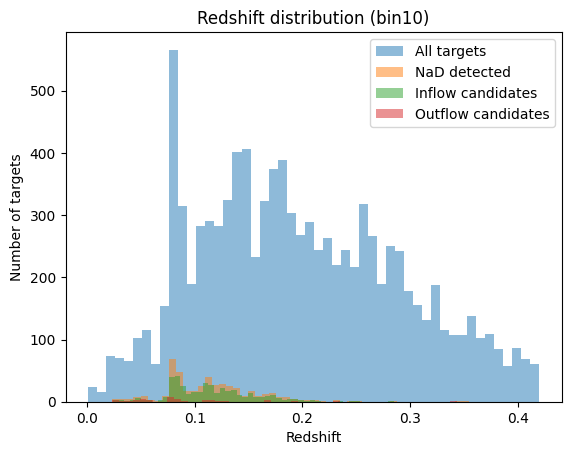

In [24]:
plt.hist(spectrum.z, bins=50, alpha=0.5, label='All targets', color="C0")
plt.hist(spectrum.z[[spectrum.id2index(id) for id in NaD_targetsID]], bins=50, alpha=0.5, label='NaD detected', color="C1")
plt.hist(spectrum.z[[spectrum.id2index(id) for id in inflow_targetsID]], bins=50, alpha=0.5, label='Inflow candidates', color="C2")
plt.hist(spectrum.z[[spectrum.id2index(id) for id in outflow_targetsID]], bins=50, alpha=0.5, label='Outflow candidates', color="C3")
plt.xlabel('Redshift')
plt.ylabel('Number of targets')
plt.title('Redshift distribution (bin10)')
plt.legend()
plt.savefig('redshift_distribution_bin10_all.png')
plt.show()

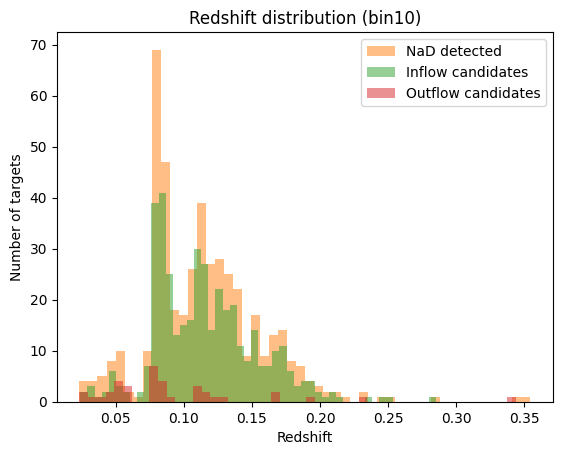

In [25]:
# plt.hist(spectrum.z, bins=50, alpha=0.5, label='All targets')
plt.hist(spectrum.z[[spectrum.id2index(id) for id in NaD_targetsID]], bins=50, alpha=0.5, label='NaD detected', color="C1")
plt.hist(spectrum.z[[spectrum.id2index(id) for id in inflow_targetsID]], bins=50, alpha=0.5, label='Inflow candidates', color="C2")
plt.hist(spectrum.z[[spectrum.id2index(id) for id in outflow_targetsID]], bins=50, alpha=0.5, label='Outflow candidates', color="C3")
plt.xlabel('Redshift')
plt.ylabel('Number of targets')
plt.title('Redshift distribution (bin10)')
plt.legend()
plt.savefig('redshift_distribution_bin10.png')
plt.show()